In [2]:
import pickle
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import chess
import tensorflow as tf
from tensorflow.keras import layers, regularizers

In [3]:
import sys
import os
root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
from src.logic.board import Board

In [4]:
MAX_DATA = 1000000

print("Loading data from pickle...")
with open(os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "mt.pkl"), 'rb') as f:
    data = pickle.load(f)

items = list(data.items())
np.random.shuffle(items)

if MAX_DATA:
    items = items[:MAX_DATA]

# Split into Train (which will later be split again for validation) and Test
split_index = int(len(items) * 0.8)
train_items = items[:split_index]
test_items = items[split_index:]

def process_items(item_list):
    X, y = [], []
    length = len(item_list)
    for i, (fen, score) in enumerate(item_list):
        X.append(Board.engine_to_tensor(chess.Board(fen)))
        y.append(score)
        
        percentage = ((i + 1) / length) * 100
        print(f"\rProgress: {percentage:.2f}%", end="", flush=True)
    print()
    return np.array(X, dtype=np.int8), np.array(y, dtype=np.float32)

print(f"Creating training data length {len(train_items)}")
X_train, y_train = process_items(train_items)

print(f"Creating testing data length{len(test_items)}")
X_test, y_test = process_items(test_items)

Loading data from pickle...
Creating training data length 800000
Progress: 1.49%

KeyboardInterrupt: 

In [33]:
inputs = layers.Input(shape=(8, 8, 18))

# 1. Very light first layer to find basic pieces
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x) # Kept because it helps training but is virtually "free" during inference

# 2. Second layer to find basic interactions
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)

# 3. Quick decision making
x = layers.Flatten()(x)

# A single, small dense layer instead of multiple massive ones
x = layers.Dense(128, activation='relu')(x)

# Final output
outputs = layers.Dense(1, activation='tanh')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

Starting training...
Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - loss: 0.0735 - mae: 0.0766 - val_loss: 0.0728 - val_mae: 0.0750
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - loss: 0.0735 - mae: 0.0766 - val_loss: 0.0728 - val_mae: 0.0755
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - loss: 0.0735 - mae: 0.0765 - val_loss: 0.0728 - val_mae: 0.0747
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - loss: 0.0735 - mae: 0.0766 - val_loss: 0.0728 - val_mae: 0.0790
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 54s 11ms/step - loss: 0.0735 - mae: 0.0767 - val_loss: 0.0728 - val_mae: 0.0778
Testing model...
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0729 - mae: 0.0757
Test MSE: 0.0729
Test MAE: 0.0757


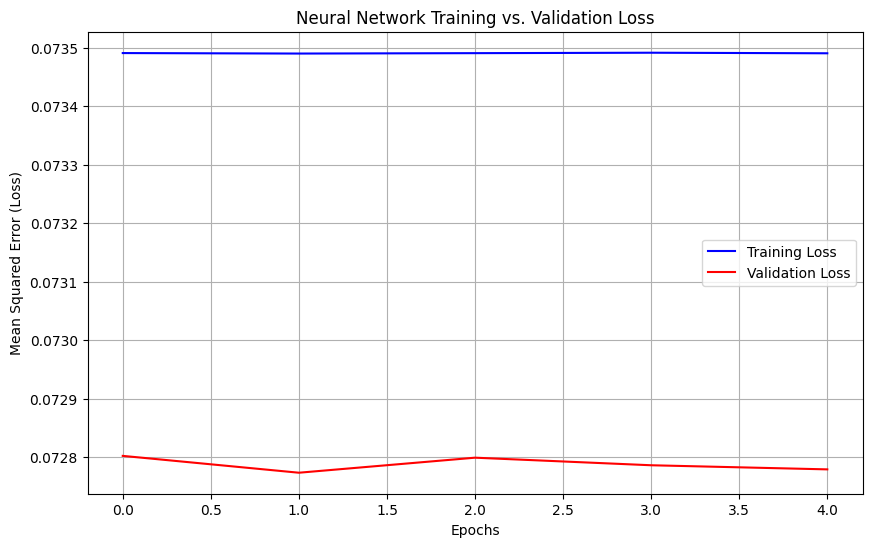

In [35]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,               
    restore_best_weights=True 
)

print("Starting training...")
history = model.fit(
    X_train, y_train, 
    epochs=10,               
    batch_size=128,            
    validation_split=0.2,
    callbacks=[early_stop]    
)

print("Testing model...")
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Generate the loss graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Neural Network Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(True)
plt.show()


In [36]:
model.save('evaluator.keras')

In [37]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 8, 8, 18)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 32)       │         5,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,645,541 (6.28 MB)

 Trainable params: 548,449 (2.09 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 1,096,900 (4.18 MB)